In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import shap
from sklearn.inspection import PartialDependenceDisplay

In [8]:
FEATURES = ['age', 'age2', 'sex', 'bmi', 'children', 'smoker', 'smoker_bmi', 'smoker_age', 'smoker_obese', 'obese', 'region']
final_df = pd.read_csv('/content/final_df.csv')
final_df = final_df.drop_duplicates().reset_index(drop=True)
final_df = final_df.drop(columns=[final_df.columns[0]])
X = final_df[FEATURES].values
y = final_df["charges_log"].values

print(final_df)

      age  sex     bmi  children  smoker  region      charges  bmi_category  \
0      19    0  27.900         0       1       3  16884.92400             2   
1      18    1  33.770         1       0       2   1725.55230             3   
2      28    1  33.000         3       0       2   4449.46200             3   
3      33    1  22.705         0       0       1  21984.47061             1   
4      32    1  28.880         0       0       1   3866.85520             2   
...   ...  ...     ...       ...     ...     ...          ...           ...   
1332   50    1  30.970         3       0       1  10600.54830             3   
1333   18    0  31.920         0       0       0   2205.98080             3   
1334   18    0  36.850         0       0       2   1629.83350             3   
1335   21    0  25.800         0       0       3   2007.94500             2   
1336   61    0  29.070         0       1       1  29141.36030             2   

      age_group  age2  obese  smoker_age  smoker_bm

In [9]:
print(f"final_df describe:\n{final_df.describe()}\n")
print(f"final_df dtype:\n{final_df.dtypes}")

final_df describe:
               age          sex          bmi     children       smoker  \
count  1337.000000  1337.000000  1337.000000  1337.000000  1337.000000   
mean     39.222139     0.504862    30.663452     1.095737     0.204936   
std      14.044333     0.500163     6.100468     1.205571     0.403806   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      27.000000     0.000000    26.290000     0.000000     0.000000   
50%      39.000000     1.000000    30.400000     1.000000     0.000000   
75%      51.000000     1.000000    34.700000     2.000000     0.000000   
max      64.000000     1.000000    53.130000     5.000000     1.000000   

            region       charges  bmi_category    age_group         age2  \
count  1337.000000   1337.000000   1337.000000  1337.000000  1337.000000   
mean      1.516081  13279.121487      2.338070     1.110696  1735.471952   
std       1.105208  12110.359656      0.805665     0.947585  1125.562335   
min       

In [10]:
# OLS on log charges
ols = LinearRegression().fit(X, y)
ols_r2 = r2_score(final_df["charges"], np.exp(ols.predict(X)))

print("=" * 50)
print("OLS on log(charges)")
print("=" * 50)
for name, coef in zip(FEATURES, ols.coef_):
    print(f"  {name:<14} {coef:+.4f}")
print(f"  intercept      {ols.intercept_:+.4f}")
print(f"\n  R² ($ scale):  {ols_r2:.3f}")

OLS on log(charges)
  age            +0.0599
  age2           -0.0002
  sex            -0.0858
  bmi            +0.0005
  children       +0.0969
  smoker         +2.0081
  smoker_bmi     +0.0184
  smoker_age     -0.0335
  smoker_obese   +0.5134
  obese          +0.0026
  region         -0.0532
  intercept      +6.8323

  R² ($ scale):  0.833


In [38]:
# Random Forest

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

rf = RandomForestRegressor(n_estimators=44, random_state=42)
rf.fit(X_train, y_train)

# Predictions (log scale → dollar scale)
y_pred_train = np.exp(rf.predict(X_train))
y_pred_test  = np.exp(rf.predict(X_test))

y_true_train = np.exp(y_train)
y_true_test  = np.exp(y_test)

rf_r2_train = r2_score(y_true_train, y_pred_train)
rf_r2_test  = r2_score(y_true_test,  y_pred_test)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

print("\n" + "=" * 50)
print("Random Forest")
print("=" * 50)
print("\n  Feature importances:")
for feat, imp in importances.items():
    print(f"    {feat:<14} {imp:.3f}")
print(f"\n  R² Train ($ scale):  {rf_r2_train:.3f}")
print(f"  R² Test  ($ scale):  {rf_r2_test:.3f}")

# ── Cross-Validation ──────────────────────────────────────────────────────────
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")
print(f"\n  CV R² scores:  {cv_scores.round(3)}")
print(f"  Mean CV R²:    {cv_scores.mean():.3f}")
print(f"  Std  CV R²:    {cv_scores.std():.3f}")


Random Forest

  Feature importances:
    smoker_bmi     0.286
    age            0.202
    age2           0.178
    smoker_age     0.097
    bmi            0.084
    smoker         0.058
    children       0.051
    region         0.025
    sex            0.012
    obese          0.005
    smoker_obese   0.002

  R² Train ($ scale):  0.957
  R² Test  ($ scale):  0.897

  CV R² scores:  [0.763 0.828 0.754 0.779 0.781]
  Mean CV R²:    0.781
  Std  CV R²:    0.025


In [33]:
ols_cv = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

print(f"OLS CV R² scores: {ols_cv.round(3)}")
print(f"Mean CV R²:       {ols_cv.mean():.3f}")
print(f"Std CV R²:        {ols_cv.std():.3f}")

OLS CV R² scores: [0.885 0.728 0.899 0.829 0.8  ]
Mean CV R²:       0.828
Std CV R²:        0.062


Cross validation shows OLS performs better than RF in general. However, while OLS gives a better general picture, RF learns the shape of the data, rather than assuming it. This allows for more flexibility, which is worth exploring in the dataset given the non-trivial aspects of the data which we will see later.

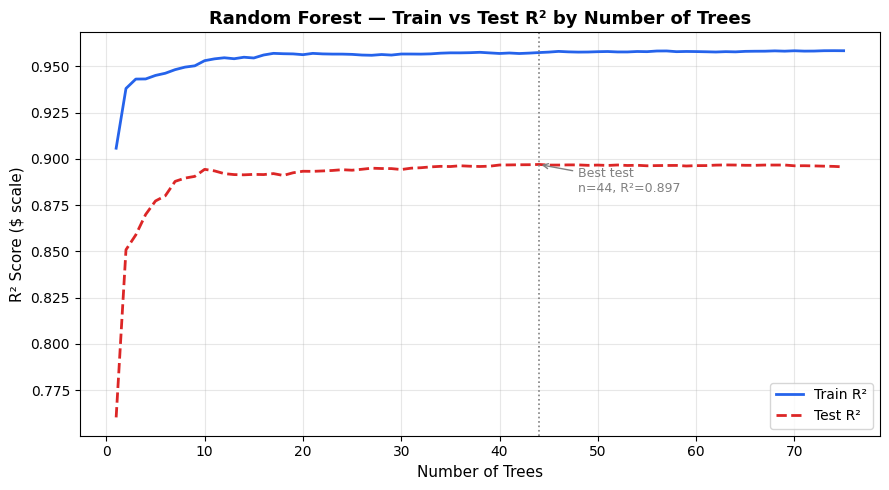

In [34]:
# ── Loss Curve (staged R² vs n_estimators) ────────────────────────────────────
rf_staged = RandomForestRegressor(n_estimators=75, random_state=42, warm_start=True)

train_r2_curve, test_r2_curve, n_trees_range = [], [], range(1, 76)

for n in n_trees_range:
    rf_staged.set_params(n_estimators=n)
    rf_staged.fit(X_train, y_train)

    train_r2_curve.append(r2_score(y_true_train, np.exp(rf_staged.predict(X_train))))
    test_r2_curve.append(r2_score(y_true_test,  np.exp(rf_staged.predict(X_test))))

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(n_trees_range, train_r2_curve, label="Train R²", linewidth=2, color="#2563EB")
ax.plot(n_trees_range, test_r2_curve,  label="Test R²",  linewidth=2, color="#DC2626", linestyle="--")

# Mark best test R²
best_n   = int(np.argmax(test_r2_curve)) + 1
best_r2  = max(test_r2_curve)
ax.axvline(best_n, color="gray", linestyle=":", linewidth=1.2)
ax.annotate(f"Best test\nn={best_n}, R²={best_r2:.3f}",
            xy=(best_n, best_r2),
            xytext=(best_n + 4, best_r2 - 0.015),
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray"))

ax.set_xlabel("Number of Trees", fontsize=11)
ax.set_ylabel("R² Score ($ scale)", fontsize=11)
ax.set_title("Random Forest — Train vs Test R² by Number of Trees", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The loss function tells us that it should be relatively safe to use an ideal 44 trees.

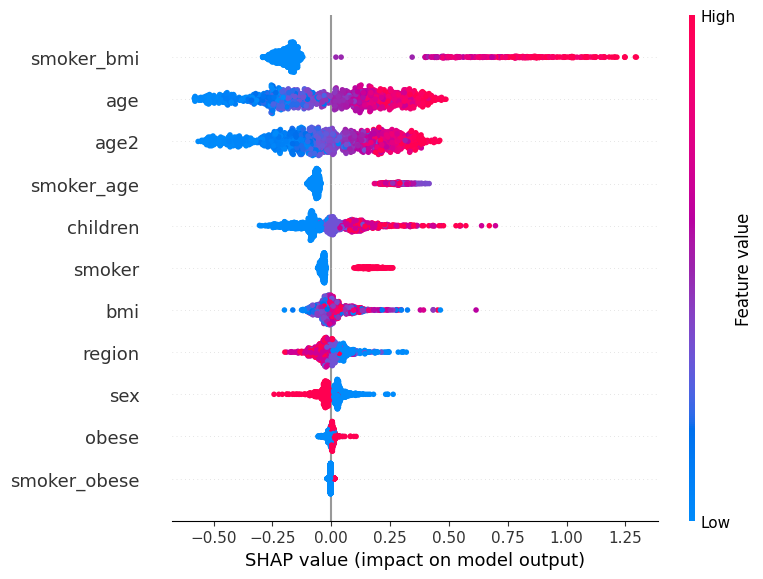

In [35]:
# SHAP values
X_named = pd.DataFrame(X, columns=FEATURES)
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_named)
shap.summary_plot(shap_values, X_named)

Very informative. Shows extreme correlations in the way we predicted. Ex: bmi_smoker shows that nonsmokers decrease cost, but smokers increase cost with high bmi. Blue applies for all non smokers no matter what, red applies to smokers with high bmi. All 11 predictors accounted for. Note the gradient in continuous predictors and solid color differences in binaries.

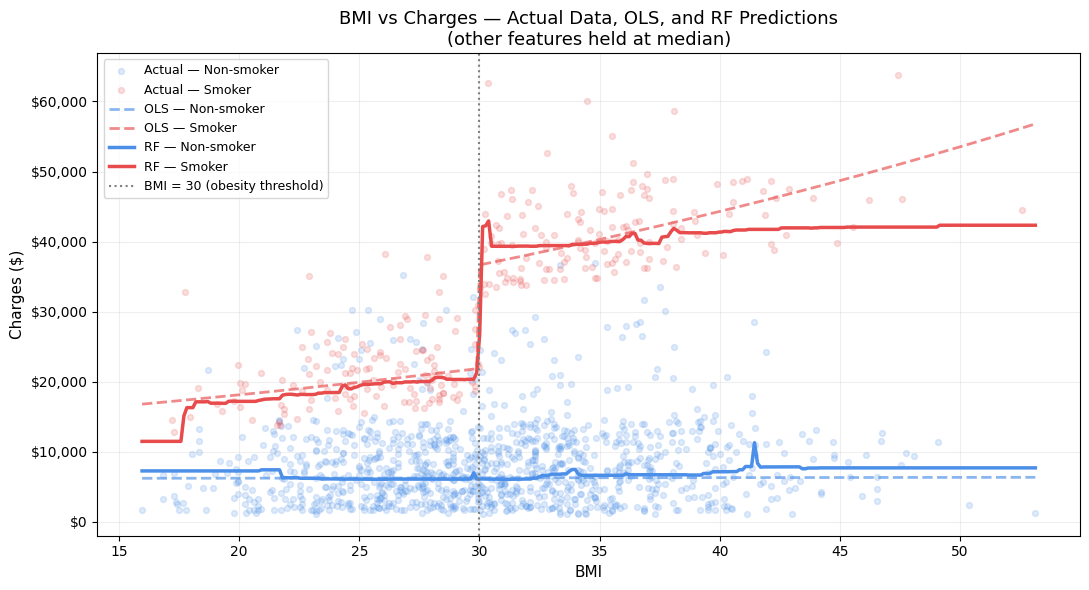

In [36]:
bmi_range = np.linspace(final_df["bmi"].min(), final_df["bmi"].max(), 300)

# This will keep non-relevant predictors consistent at the median so that they do not affect the plot.
def build_profile(bmi_arr, smoker_val):
    """Build a feature matrix over a BMI range with median values for other features."""
    age_med    = final_df["age"].median()
    age2_med   = age_med ** 2
    sex_med    = final_df["sex"].median()
    children_med = final_df["children"].median()
    region_med = final_df["region"].median()
    obese_arr  = (bmi_arr >= 30).astype(int)

    return np.column_stack([
        np.full(len(bmi_arr), age_med),
        np.full(len(bmi_arr), age2_med),
        np.full(len(bmi_arr), sex_med),
        bmi_arr,
        np.full(len(bmi_arr), children_med),
        np.full(len(bmi_arr), smoker_val),
        bmi_arr * smoker_val,
        np.full(len(bmi_arr), age_med * smoker_val),
        obese_arr * smoker_val,
        obese_arr,
        np.full(len(bmi_arr), region_med),
    ])

X_smoker     = build_profile(bmi_range, smoker_val=1)
X_nonsmoker  = build_profile(bmi_range, smoker_val=0)

# OLS predictions (back-transform from log)
ols_smoker_pred    = np.exp(ols.predict(X_smoker))
ols_nonsmoker_pred = np.exp(ols.predict(X_nonsmoker))

# RF predictions (back-transform from log)
rf_smoker_pred     = np.exp(rf.predict(X_smoker))
rf_nonsmoker_pred  = np.exp(rf.predict(X_nonsmoker))

# Colors
SMOKER_COL    = "#E84B4B"   # red family
NONSMOKER_COL = "#4B8FE8"   # blue family

fig, ax = plt.subplots(figsize=(11, 6))

# Scatterplot — actual data points
smokers_mask    = final_df["smoker"] == 1
nonsmokers_mask = final_df["smoker"] == 0

ax.scatter(final_df.loc[nonsmokers_mask, "bmi"],
           final_df.loc[nonsmokers_mask, "charges"],
           color=NONSMOKER_COL, alpha=0.18, s=18, label="Actual — Non-smoker")

ax.scatter(final_df.loc[smokers_mask, "bmi"],
           final_df.loc[smokers_mask, "charges"],
           color=SMOKER_COL, alpha=0.18, s=18, label="Actual — Smoker")

# 2. Predicted OLS
ax.plot(bmi_range, ols_nonsmoker_pred,
        color=NONSMOKER_COL, alpha=0.65, linewidth=2,
        linestyle="--", label="OLS — Non-smoker")

ax.plot(bmi_range, ols_smoker_pred,
        color=SMOKER_COL, alpha=0.65, linewidth=2,
        linestyle="--", label="OLS — Smoker")

# Predicted RF
ax.plot(bmi_range, rf_nonsmoker_pred,
        color=NONSMOKER_COL, alpha=1.0, linewidth=2.5,
        linestyle="-", label="RF — Non-smoker")

ax.plot(bmi_range, rf_smoker_pred,
        color=SMOKER_COL, alpha=1.0, linewidth=2.5,
        linestyle="-", label="RF — Smoker")

# Obesity threshold
ax.axvline(30, color="gray", linestyle=":", linewidth=1.5, label="BMI = 30 (obesity threshold)")

# Plot
ax.set_title("BMI vs Charges — Actual Data, OLS, and RF Predictions\n(other features held at median)",
             fontsize=13)
ax.set_xlabel("BMI", fontsize=11)
ax.set_ylabel("Charges ($)", fontsize=11)
ax.legend(fontsize=9, loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("bmi_charges_comparison.png", dpi=150)
plt.show()

The discontinuity at BMI = 30 in the OLS prediction line reflects the inclusion of binary indicator features (obese, smoker_obese) that switch from 0 to 1 at the obesity threshold. Because OLS assigns fixed coefficients to these terms, the predicted charge jumps discretely at BMI = 30 rather than transitioning smoothly. This is a modeling artifact of encoding obesity as a threshold effect rather than a continuous one. However, replacing the binary obese term with a continuous BMI term would eliminate discontinuity. This, however, would come at the cost of model accuracy, as well as the threshold interpretation.

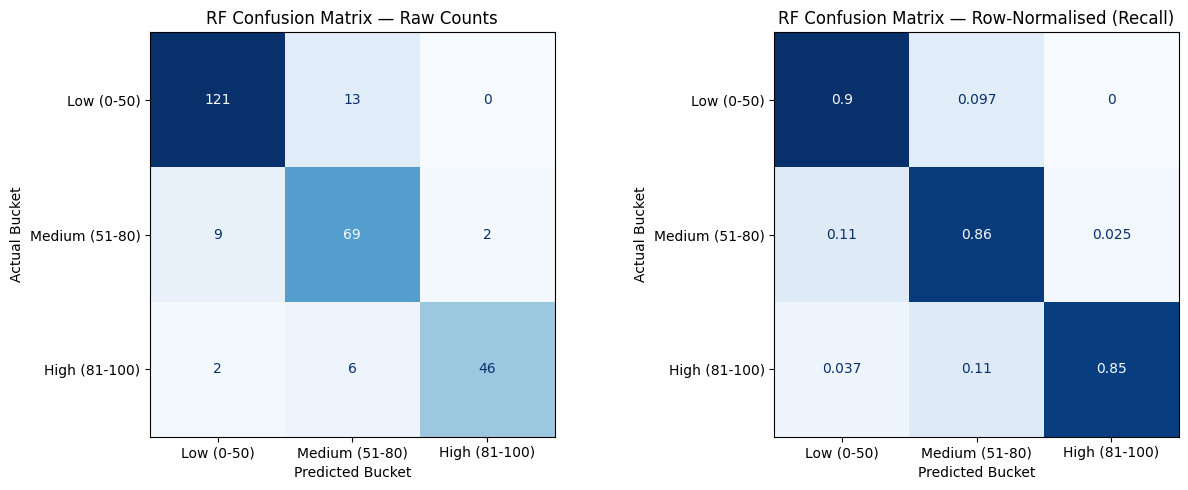

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get RF predictions (back-transformed)
rf_preds = np.exp(rf.predict(X_test))
actual   = np.exp(y_test)

# Define percentile-based bucket boundaries
p50 = np.percentile(actual, 50)
p80 = np.percentile(actual, 80)

def bucket(arr, p50, p80):
    labels = np.empty(len(arr), dtype=object)
    labels[arr <= p50] = "Low (0-50)"
    labels[(arr > p50) & (arr <= p80)] = "Medium (51-80)"
    labels[arr > p80] = "High (81-100)"
    return labels

actual_buckets = bucket(actual, p50, p80)
pred_buckets   = bucket(rf_preds, p50, p80)

# Confusion matrix
# Modified the order list to match the actual labels generated by the bucket function
order = ["Low (0-50)", "Medium (51-80)", "High (81-100)"]
cm    = confusion_matrix(actual_buckets, pred_buckets, labels=order)

# Raw counts plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("RF Confusion Matrix — Raw Counts", fontsize=12)
axes[0].set_xlabel("Predicted Bucket")
axes[0].set_ylabel("Actual Bucket")

# Row-normalised (recall) plot
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=order)
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("RF Confusion Matrix — Row-Normalised (Recall)", fontsize=12)
axes[1].set_xlabel("Predicted Bucket")
axes[1].set_ylabel("Actual Bucket")

plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

This plot shows a high accuracy in RF predictions within the bucket ranges in charges. It is generally much more accurate in the low cost range, while it tends to underestimate high costs. This is natural and expected in RF analysis. RF estimates based on the neighbors, and there aren't enough high-cost neighbors to accurately predict them. RF is thus unable to extrapolate any more than the 75 trees we have set.